In [6]:
import tensorflow as tf
print(tf.__version__)



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2.15.0


In [7]:
df = pd.read_csv("cleaned_energy_data.csv", index_col=0, parse_dates=True)

print(df.shape)
print(df.head())

C:\Users\Admin\AppData\Local\Temp\ipykernel_13376\2414042368.py:1: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_energy_data.csv", index_col=0, parse_dates=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13376\2414042368.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("cleaned_energy_data.csv", index_col=0, parse_dates=True)


(503911, 31)
            use [kW]  gen [kW]  House overall [kW]  Dishwasher [kW]  \
time                                                                  
1451624400  0.932833  0.003483            0.932833         0.000033   
1451624401  0.934333  0.003467            0.934333         0.000000   
1451624402  0.931817  0.003467            0.931817         0.000017   
1451624403  1.022050  0.003483            1.022050         0.000017   
1451624404  1.139400  0.003467            1.139400         0.000133   

            Furnace 1 [kW]  Furnace 2 [kW]  Home office [kW]  Fridge [kW]  \
time                                                                        
1451624400        0.020700        0.061917          0.442633     0.124150   
1451624401        0.020717        0.063817          0.444067     0.124000   
1451624402        0.020700        0.062317          0.446067     0.123533   
1451624403        0.106900        0.068517          0.446583     0.123133   
1451624404        0.236933 

In [22]:
df = pd.get_dummies(df, columns=['icon', 'summary', 'cloudCover'])

In [23]:
df = df.fillna(method='ffill')
df = df.dropna()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8356\1467864381.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [24]:
target = 'House overall [kW]'
features = df.columns.tolist()
features.remove(target)

In [25]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

In [28]:
def create_sequences(data, target_col, time_steps=24):
    X = []
    y = []
    
    for i in range(len(data) - time_steps):
        X.append(data.iloc[i:i+time_steps].values)
        y.append(data.iloc[i+time_steps][target_col])
        
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df, target, time_steps=24)

print(X.shape)
print(y.shape)

(49976, 24, 56)
(49976,)


In [29]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [30]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 24, 64)            30976     
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 43425 (169.63 KB)
Trainable params: 43425 (169.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [31]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
625/625 [==============================] - 23s 28ms/step - loss: nan - val_loss: nan
Epoch 2/10
625/625 [==============================] - 15s 25ms/step - loss: nan - val_loss: nan
Epoch 3/10
625/625 [==============================] - 16s 25ms/step - loss: nan - val_loss: nan
Epoch 4/10
625/625 [==============================] - 16s 26ms/step - loss: nan - val_loss: nan
Epoch 5/10
625/625 [==============================] - 17s 27ms/step - loss: nan - val_loss: nan
Epoch 6/10
625/625 [==============================] - 16s 25ms/step - loss: nan - val_loss: nan
Epoch 7/10
625/625 [==============================] - 16s 26ms/step - loss: nan - val_loss: nan
Epoch 8/10
625/625 [==============================] - 18s 29ms/step - loss: nan - val_loss: nan
Epoch 9/10
625/625 [==============================] - 18s 29ms/step - loss: nan - val_loss: nan
Epoch 10/10
625/625 [==============================] - 17s 27ms/step - loss: nan - val_loss: nan


In [32]:
predictions = model.predict(X_test)

313/313 [==============================] - 4s 8ms/step


In [52]:
print("y_test shape:", y_test.shape)
print("predictions shape:", predictions.shape)

y_test shape: (9996,)
predictions shape: (9996,)


In [57]:
print("y_test shape:", y_test.shape)
print("predictions shape:", predictions.shape)

y_test shape: (9996,)
predictions shape: (9996,)


In [58]:
predictions = predictions.flatten()

313/313 [==============================] - 5s 13ms/step


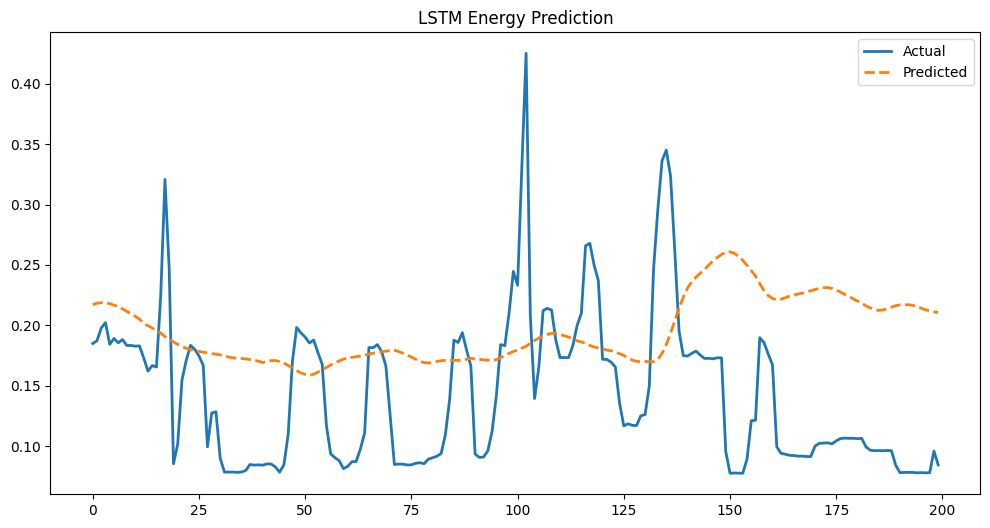

In [70]:
predictions = model.predict(X_test).flatten()

plt.figure(figsize=(12,6))
plt.plot(y_test[:200], label='Actual', linewidth=2)
plt.plot(predictions[:200], label='Predicted', linestyle='dashed', linewidth=2)
plt.legend()
plt.title("LSTM Energy Prediction")
plt.show()

In [67]:
from tensorflow.keras.layers import GRU, Dense, Dropout

In [68]:
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data.iloc[i:i+time_steps].values)
        y.append(data.iloc[i+time_steps]['House overall [kW]'])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df, 24)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49976, 24, 56)
y shape: (49976,)


In [42]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [43]:
model = Sequential()

model.add(GRU(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))

model.add(GRU(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 24, 128)           71424     
                                                                 
 dropout (Dropout)           (None, 24, 128)           0         
                                                                 
 gru_1 (GRU)                 (None, 64)                37248     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 108737 (424.75 KB)
Trainable params: 108737 (424.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [44]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
1250/1250 [==============================] - 51s 36ms/step - loss: nan - val_loss: nan
Epoch 2/20
1250/1250 [==============================] - 42s 34ms/step - loss: nan - val_loss: nan
Epoch 3/20
1250/1250 [==============================] - 42s 34ms/step - loss: nan - val_loss: nan
Epoch 4/20
1250/1250 [==============================] - 47s 37ms/step - loss: nan - val_loss: nan
Epoch 5/20
1250/1250 [==============================] - 46s 36ms/step - loss: nan - val_loss: nan
Epoch 6/20
1250/1250 [==============================] - 42s 34ms/step - loss: nan - val_loss: nan
Epoch 7/20
1250/1250 [==============================] - 42s 34ms/step - loss: nan - val_loss: nan
Epoch 8/20
1250/1250 [==============================] - 43s 35ms/step - loss: nan - val_loss: nan
Epoch 9/20
1250/1250 [==============================] - 43s 35ms/step - loss: nan - val_loss: nan
Epoch 10/20
1250/1250 [==============================] - 43s 34ms/step - loss: nan - val_loss: nan
Epoch 11/20
1250/12

In [71]:
predictions = model.predict(X_test)
predictions = predictions.flatten()

313/313 [==============================] - 4s 13ms/step


In [72]:
import numpy as np
dummy_pred = np.zeros((len(predictions), scaled_df.shape[1]))
dummy_pred[:, 0] = predictions  
pred_actual = scaler.inverse_transform(dummy_pred)[:, 0]
dummy_actual = np.zeros((len(y_test), scaled_df.shape[1]))
dummy_actual[:, 0] = y_test
y_actual = scaler.inverse_transform(dummy_actual)[:, 0]

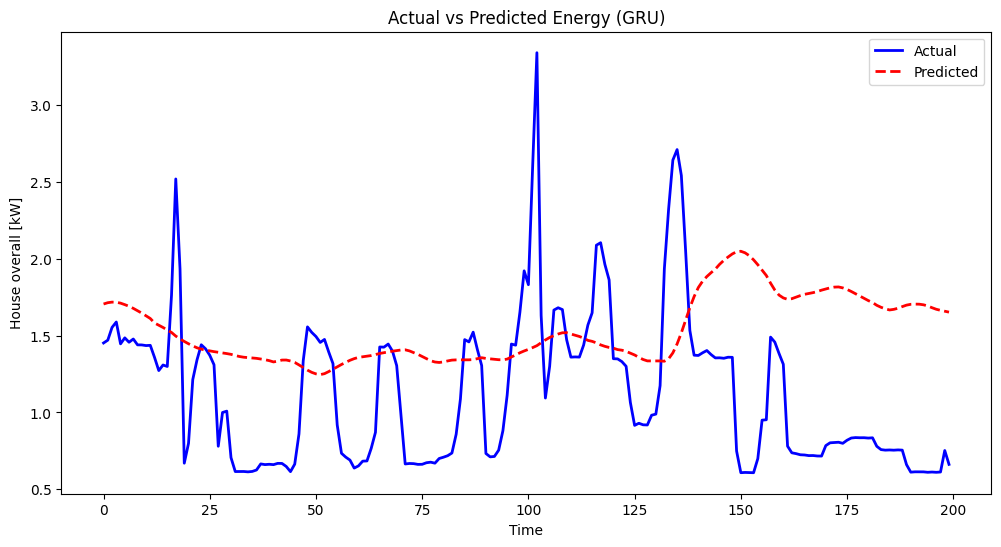

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_actual[:200], label='Actual', color='blue', linewidth=2)
plt.plot(pred_actual[:200], label='Predicted', color='red', linestyle='dashed', linewidth=2)
plt.legend()
plt.title("Actual vs Predicted Energy (GRU)")
plt.xlabel("Time")
plt.ylabel("House overall [kW]")
plt.show()